<a href="https://colab.research.google.com/github/k2herat/DL2/blob/hw4/almetov_hw4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers datasets torch scikit-learn matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 100.0 MB/s eta 0:00:0000:010:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0

In [ ]:
import torch
import numpy as np
import pandas as pd

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
from transformers import AutoTokenizer, AutoModel

model_name = "bert-large-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModel.from_pretrained(
    model_name,
    output_hidden_states=True
)

model.eval()

dataset = load_dataset("imdb")

train_dataset = dataset["train"].shuffle(seed=42).select(range(1000))
test_dataset = dataset["test"].shuffle(seed=42).select(range(500))

print(train_dataset)
print(test_dataset)

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-large-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Dataset({
    features: ['text', 'label'],
    num_rows: 1000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 500
})


In [ ]:
def extract_layer_embeddings(texts):

    layer_embeddings = None

    with torch.no_grad():

        for text in tqdm(texts):

            inputs = tokenizer(
                text,
                return_tensors="pt",
                truncation=True,
                padding=True,
                max_length=256
            )

            outputs = model(**inputs)

            hidden_states = outputs.hidden_states

            if layer_embeddings is None:
                layer_embeddings = [[] for _ in range(len(hidden_states))]

            for layer_idx, layer_hidden in enumerate(hidden_states):

                cls_embedding = layer_hidden[:,0,:].squeeze().numpy()

                layer_embeddings[layer_idx].append(cls_embedding)

    layer_embeddings = [
        np.array(layer)
        for layer in layer_embeddings
    ]

    return layer_embeddings

In [ ]:
X_train_layers = extract_layer_embeddings(train_dataset["text"])
X_test_layers = extract_layer_embeddings(test_dataset["text"])

y_train = np.array(train_dataset["label"])
y_test = np.array(test_dataset["label"])

100%|██████████| 500/500 [06:38<00:00,  1.25it/s]


In [ ]:
results = []

for layer_idx in range(len(X_train_layers)):

    clf = LogisticRegression(
        max_iter=2000
    )

    clf.fit(
        X_train_layers[layer_idx],
        y_train
    )

    preds = clf.predict(
        X_test_layers[layer_idx]
    )

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    results.append({
        "layer": layer_idx,
        "accuracy": acc,
        "f1": f1
    })

    print(
        f"Layer {layer_idx}: "
        f"Accuracy={acc:.4f}, "
        f"F1={f1:.4f}"
    )

Layer 0: Accuracy=0.5080, F1=0.0000
Layer 1: Accuracy=0.6400, F1=0.6154
Layer 2: Accuracy=0.7780, F1=0.7711
Layer 3: Accuracy=0.7900, F1=0.7808
Layer 4: Accuracy=0.7620, F1=0.7484
Layer 5: Accuracy=0.7620, F1=0.7536
Layer 6: Accuracy=0.7720, F1=0.7625
Layer 7: Accuracy=0.7780, F1=0.7702
Layer 8: Accuracy=0.7660, F1=0.7568
Layer 9: Accuracy=0.7580, F1=0.7453
Layer 10: Accuracy=0.7660, F1=0.7568
Layer 11: Accuracy=0.7640, F1=0.7602
Layer 12: Accuracy=0.7520, F1=0.7384
Layer 13: Accuracy=0.7420, F1=0.7307
Layer 14: Accuracy=0.7680, F1=0.7603
Layer 15: Accuracy=0.7400, F1=0.7368
Layer 16: Accuracy=0.7560, F1=0.7490
Layer 17: Accuracy=0.7560, F1=0.7479
Layer 18: Accuracy=0.7960, F1=0.7952
Layer 19: Accuracy=0.7860, F1=0.7812
Layer 20: Accuracy=0.7900, F1=0.7879
Layer 21: Accuracy=0.8000, F1=0.7942
Layer 22: Accuracy=0.7860, F1=0.7847
Layer 23: Accuracy=0.8140, F1=0.8151
Layer 24: Accuracy=0.8120, F1=0.8082


In [ ]:
results_df = pd.DataFrame(results)

results_df

,layer,accuracy,f1
0,0,0.508,0.000000
1,1,0.640,0.615385
2,2,0.778,0.771134
3,3,0.790,0.780793
4,4,0.762,0.748414
5,5,0.762,0.753623
6,6,0.772,0.762500
7,7,0.778,0.770186
8,8,0.766,0.756757
9,9,0.758,0.745263


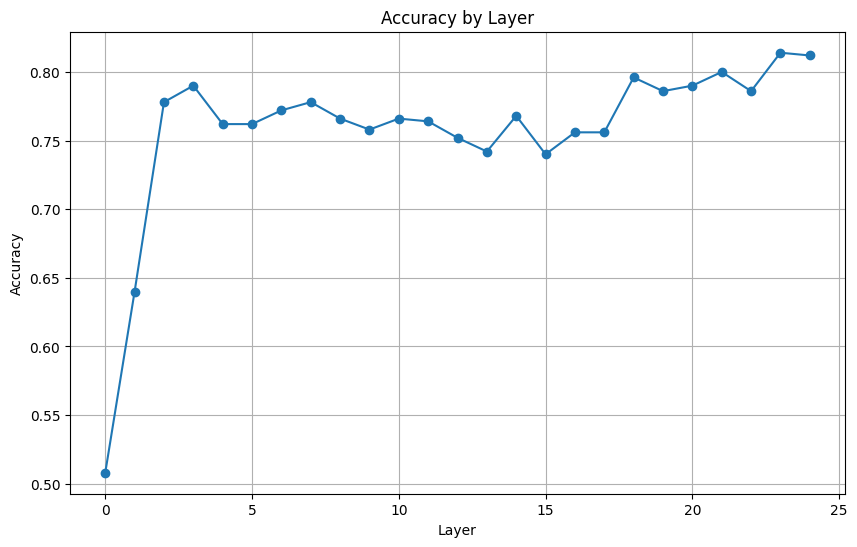

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    results_df["layer"],
    results_df["accuracy"],
    marker="o"
)

plt.xlabel("Layer")
plt.ylabel("Accuracy")
plt.title("Accuracy by Layer")

plt.grid()

plt.show()

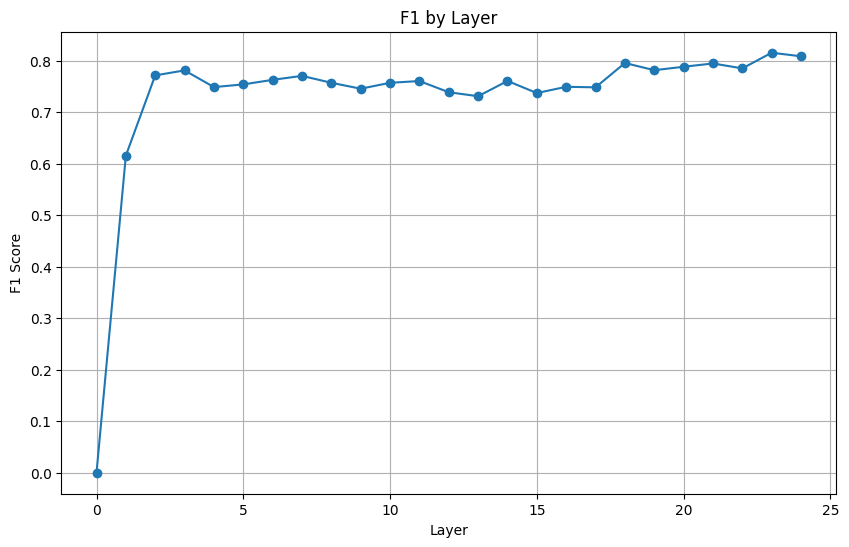

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    results_df["layer"],
    results_df["f1"],
    marker="o"
)

plt.xlabel("Layer")
plt.ylabel("F1 Score")
plt.title("F1 by Layer")

plt.grid()

plt.show()

In [ ]:
top3 = results_df.sort_values(
    by="accuracy",
    ascending=False
).head(3)

print(top3)

    layer  accuracy        f1
23     23     0.814  0.815109
24     24     0.812  0.808163
21     21     0.800  0.794239


In [ ]:
best_layer = int(
    results_df.sort_values(
        by="accuracy",
        ascending=False
    ).iloc[0]["layer"]
)

print("Best layer:", best_layer)

Best layer: 23


In [ ]:
X_vis = X_test_layers[best_layer][:300]
y_vis = y_test[:300]

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X_vis)

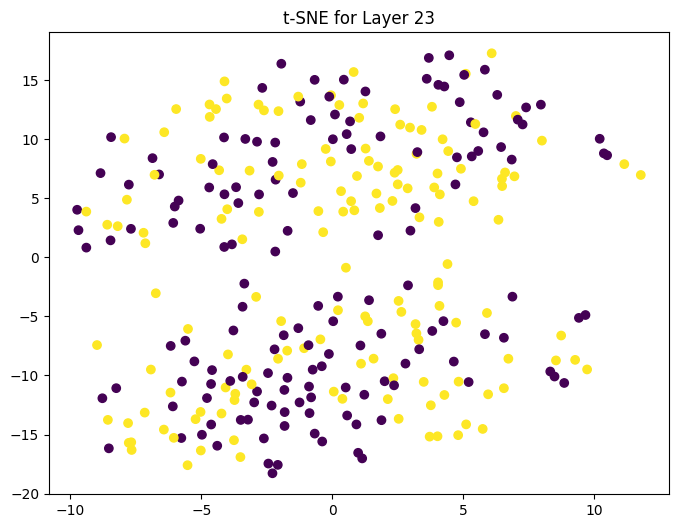

In [ ]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=y_vis
)

plt.title(
    f"t-SNE for Layer {best_layer}"
)

plt.show()

In [ ]:
top_layers = top3["layer"].tolist()

for layer in top_layers:

    clf = LogisticRegression(
        max_iter=2000
    )

    clf.fit(
        X_train_layers[layer],
        y_train
    )

    preds = clf.predict(
        X_test_layers[layer]
    )

    print(
        f"Layer {layer}:",
        accuracy_score(y_test, preds),
        f1_score(y_test, preds)
    )

Layer 23: 0.814 0.8151093439363817
Layer 24: 0.812 0.8081632653061225
Layer 21: 0.8 0.7942386831275721


В проведённом эксперименте максимальные значения Accuracy и F1 были получены на последних слоях модели BERT Large. Это свидетельствует о том, что для задачи классификации эмоций наиболее полезными оказались высокоуровневые семантические представления, формируемые в верхней части сети.

При этом ранние слои показывали более низкие результаты, что объясняется преобладанием в них лексической и синтаксической информации. По мере продвижения по сети качество классификации возрастало, достигая максимума на последних слоях.

Полученный результат не противоречит выводам статьи HiProbe-VAD. Хотя в ряде задач наиболее информативными оказываются промежуточные слои, распределение информации зависит от конкретной модели и рассматриваемой задачи. Для задачи распознавания эмоций последние слои модели оказались наиболее информативными.